In [1]:
# ============================ STF VAR WORKFLOW ============================
# CELL 1: IMPORTS
import datetime, warnings, contextlib, io, itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from arch.unitroot import ADF
except ImportError:
    !pip install arch -q
    from arch.unitroot import ADF

from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import grangercausalitytests

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (14, 7)

In [2]:
# CELL 2: CONFIG + DATA LOADING
DATA_SOURCE = "csv"                  # 'csv' or 'yfinance' (yfinance: 1m/5m/15m/1h only)
TIMEFRAME = "1m"                     # 'tick' | '1s' | '1m' | '5m' | '15m' | '1h'
TRAINING_DATA_MODE = "recent_bars"   # 'recent_bars' | 'full' | 'custom_range'
START_DATE = "2024-01-01"
END_DATE = datetime.date.today().strftime("%Y-%m-%d")

# STF -> use LESS, RECENT data (intraday relationships drift with session/vol regime). In BARS.
TRAIN_BARS     = {"tick": 3600, "1s": 3600, "1m": 1500, "5m": 1000, "15m": 800, "1h": 600}
MAX_LAGS       = {"tick": 10,   "1s": 10,   "1m": 10,   "5m": 10,   "15m": 10,  "1h": 8}
FORECAST_STEPS = {"tick": 60,   "1s": 60,   "1m": 30,   "5m": 24,   "15m": 16,  "1h": 12}
FFILL_LIMIT    = {"tick": 10,   "1s": 10,   "1m": 0,    "5m": 0,    "15m": 0,   "1h": 0}
LAG_CRITERION = "bic"                # BIC = fewer lags -> safer on short windows
TICK_GRID = "1s"                     # ticks are irregular -> put both instruments on this common grid
GAP_MULT = 3                         # gap > GAP_MULT bars = session break -> return masked

INSTRUMENTS = [
    {"alias": "NAS100", "yf_ticker": "NQ=F", "csv_file_path": r"D:\1M indices data\nas100_usd_1m.csv", "csv_column": "Close"},
    {"alias": "spx500", "yf_ticker": "ES=F", "csv_file_path": r"D:\1M indices data\spx500_usd_1m.csv", "csv_column": "Close"},
    # tick files: set "csv_column" to "bid", "ask" or "price"
]

BAR_TD = {"tick": pd.Timedelta(TICK_GRID), "1s": pd.Timedelta("1s"), "1m": pd.Timedelta("1min"),
          "5m": pd.Timedelta("5min"), "15m": pd.Timedelta("15min"), "1h": pd.Timedelta("1h")}
YF_MAP = {"1m": ("1m", "7d"), "5m": ("5m", "60d"), "15m": ("15m", "60d"), "1h": ("1h", "730d")}

DATE_NAMES  = ["date", "datetime", "time", "timestamp", "formatted date"]
PRICE_NAMES = ["close", "c", "price", "last", "bid"]


def read_csv_series(inst):
    df = pd.read_csv(inst["csv_file_path"])
    df.columns = df.columns.str.strip()
    date_col = next((c for c in df.columns if c.lower() in DATE_NAMES), None)
    if date_col is None:
        raise KeyError(f"No date column in {inst['csv_file_path']}: {list(df.columns)}")
    want = inst["csv_column"]
    price_col = want if want in df.columns else next(
        (c for c in df.columns if c.lower() in [want.lower(), *PRICE_NAMES]), None)
    if price_col is None:
        raise KeyError(f"No price column in {inst['csv_file_path']}: {list(df.columns)}")
    idx = pd.to_datetime(df[date_col], format="mixed")
    if getattr(idx.dt, "tz", None) is not None:
        idx = idx.dt.tz_localize(None)
    s = pd.Series(df[price_col].values, index=idx, name=inst["alias"]).sort_index()
    s = s[~s.index.duplicated(keep="last")]
    if TIMEFRAME != "tick" and s.index.to_series().diff().median() > BAR_TD[TIMEFRAME] * 1.5:
        raise ValueError(f"{inst['alias']}: source data is coarser than {TIMEFRAME}")
    return s


def load_yf():
    import yfinance as yf
    if TIMEFRAME not in YF_MAP:
        raise ValueError("yfinance has no tick/1s data - use DATA_SOURCE='csv'")
    interval, period = YF_MAP[TIMEFRAME]
    tk = [i["yf_ticker"] for i in INSTRUMENTS]
    raw = yf.download(tk, period=period, interval=interval, progress=False)["Close"]
    if isinstance(raw, pd.Series):
        raw = raw.to_frame(tk[0])
    raw = raw.rename(columns={i["yf_ticker"]: i["alias"] for i in INSTRUMENTS})
    raw = raw[[i["alias"] for i in INSTRUMENTS]]
    if raw.index.tz is not None:
        raw.index = raw.index.tz_localize(None)
    return raw


def load_prices():
    if DATA_SOURCE == "yfinance":
        df = load_yf()
    else:
        df = pd.concat([read_csv_series(i) for i in INSTRUMENTS], axis=1)
    df = df.sort_index().resample(BAR_TD[TIMEFRAME]).last()   # common time grid
    if FFILL_LIMIT[TIMEFRAME]:
        df = df.ffill(limit=FFILL_LIMIT[TIMEFRAME])           # only fill short holes, never session breaks
    df = df.dropna()
    total = len(df)
    if TRAINING_DATA_MODE == "recent_bars":
        df = df.tail(TRAIN_BARS[TIMEFRAME])
    elif TRAINING_DATA_MODE == "custom_range":
        df = df.loc[START_DATE:END_DATE]
    print(f"[{TIMEFRAME}] using {len(df)} bars of {total} | {df.index[0]} -> {df.index[-1]}")
    if len(df) < 500:
        print("WARNING: < 500 bars - reduce MAX_LAGS or use more data.")
    return df


data = load_prices()
data.tail()

[1m] using 1500 bars of 349256 | 2026-09-27 22:00:00 -> 2026-09-29 00:00:00


,NAS100,spx500
timestamp,,
2026-09-28 23:56:00,30361.6,7701.0
2026-09-28 23:57:00,30356.6,7700.3
2026-09-28 23:58:00,30360.6,7700.5
2026-09-28 23:59:00,30344.1,7698.5
2026-09-29 00:00:00,30341.3,7697.0


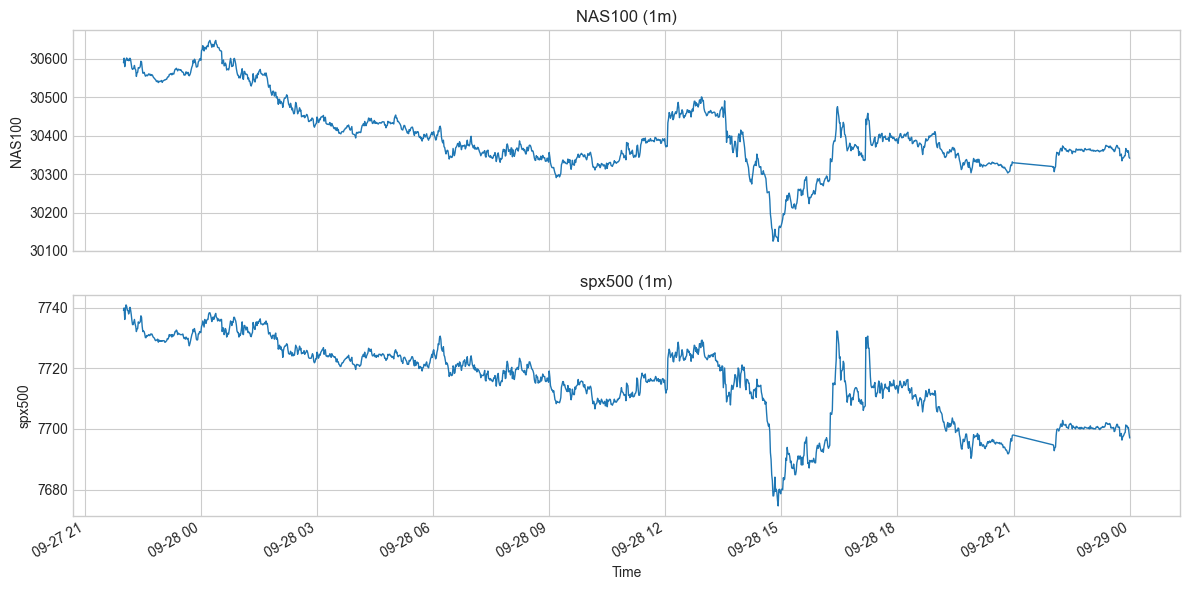

In [3]:
# CELL 3: FIGURE 1 - TIME PLOTS (LEVELS)
n = len(data.columns)
fig, axs = plt.subplots(n, 1, sharex=True, figsize=(12, 3 * n))
for ax, col in zip(np.atleast_1d(axs), data.columns):
    data[col].plot(ax=ax, linewidth=1, xlabel="Time", ylabel=col, title=f"{col} ({TIMEFRAME})")
fig.tight_layout()
plt.show()

In [4]:
# CELL 4: FIGURE 2 - ADF TEST ON LEVELS (5% level, trend='n', BIC)
def adf_table(df):
    rows = {}
    for c in df.columns:
        a = ADF(df[c].dropna(), trend="n", method="bic")
        rows[c] = {"ADF Test Statistic": a.stat, "5% Critical Value": a.critical_values["5%"],
                   "p-value": a.pvalue, "Stationary": a.stat < a.critical_values["5%"]}
    return pd.DataFrame(rows).T.round(4)

print("--- ADF on LEVELS (Stationary=False -> unit root) ---")
adf_table(data)

--- ADF on LEVELS (Stationary=False -> unit root) ---


,ADF Test Statistic,5% Critical Value,p-value,Stationary
NAS100,-0.708578,-1.941181,0.408996,False
spx500,-0.694164,-1.941181,0.415069,False


Masked 1 session gaps -> 1498 return rows


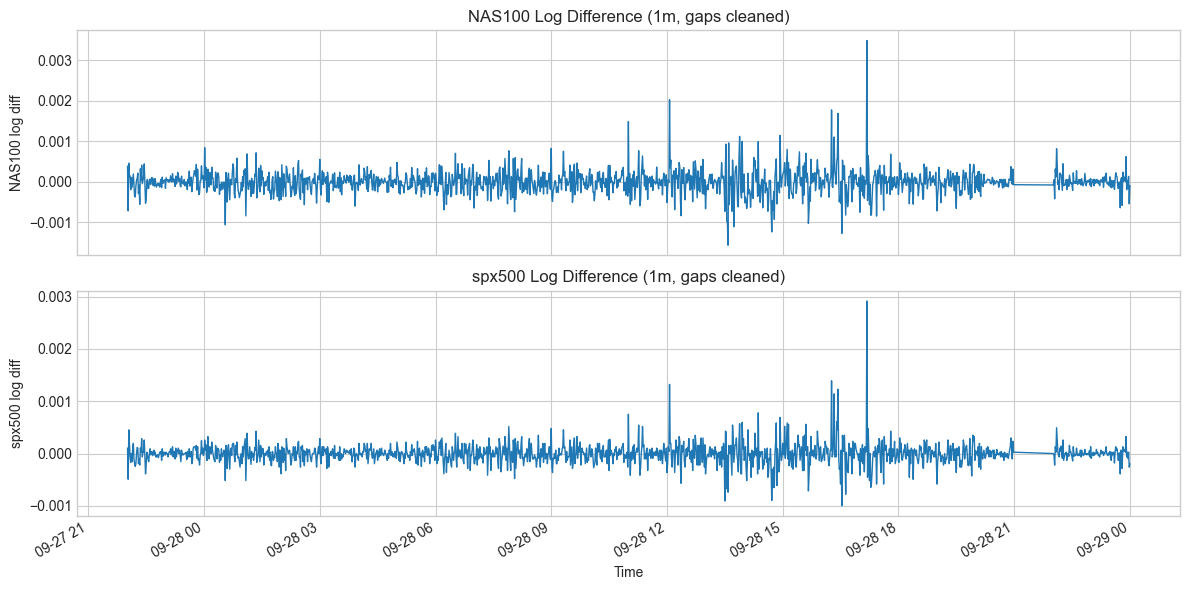

--- ADF on LOG-DIFFERENCED data ---


,ADF Test Statistic,5% Critical Value,p-value,Stationary
NAS100,-37.783758,-1.941181,0.0,True
spx500,-39.388116,-1.941181,0.0,True


In [5]:
# CELL 5: FIGURES 3 & 4 - LOG DIFFERENCE (SESSION GAPS MASKED) + ADF
diff_data = np.log(data).diff()
gap = data.index.to_series().diff() > GAP_MULT * BAR_TD[TIMEFRAME]
diff_data[gap.values] = np.nan          # overnight/weekend jumps are not real returns
diff_data = diff_data.dropna()
print(f"Masked {int(gap.sum())} session gaps -> {len(diff_data)} return rows")

fig, axs = plt.subplots(n, 1, sharex=True, figsize=(12, 3 * n))
for ax, col in zip(np.atleast_1d(axs), diff_data.columns):
    diff_data[col].plot(ax=ax, linewidth=1, xlabel="Time", ylabel=f"{col} log diff",
                        title=f"{col} Log Difference ({TIMEFRAME}, gaps cleaned)")
fig.tight_layout()
plt.show()

print("--- ADF on LOG-DIFFERENCED data ---")
adf_table(diff_data)

In [6]:
# CELL 6: GRANGER CAUSALITY (all ordered pairs)
def granger(df, cause, effect, maxlag=4):
    with contextlib.redirect_stdout(io.StringIO()):
        r = grangercausalitytests(df[[effect, cause]], maxlag=maxlag)
    return pd.DataFrame([{
        "Lag": l,
        "F-Stat": round(r[l][0]["ssr_ftest"][0], 4),
        "p-value": round(r[l][0]["ssr_ftest"][1], 4),
        "Significant (p<0.05)": r[l][0]["ssr_ftest"][1] < 0.05} for l in range(1, maxlag + 1)])

for a, b in itertools.permutations(diff_data.columns, 2):
    print(f"\n--- Does {a} Granger-cause {b}? ---")
    print(granger(diff_data, cause=a, effect=b).to_string(index=False))


--- Does NAS100 Granger-cause spx500? ---
 Lag  F-Stat  p-value  Significant (p<0.05)
   1  8.0157   0.0047                  True
   2  4.4852   0.0114                  True
   3  3.8864   0.0088                  True
   4  2.9479   0.0193                  True

--- Does spx500 Granger-cause NAS100? ---
 Lag  F-Stat  p-value  Significant (p<0.05)
   1  4.0783   0.0436                  True
   2  2.2717   0.1035                 False
   3  1.7860   0.1479                 False
   4  1.6085   0.1696                 False


In [7]:
# CELL 7: FIGURE 5 - LAG SELECTION
model = VAR(diff_data)
k = diff_data.shape[1]
max_l = min(MAX_LAGS[TIMEFRAME], (len(diff_data) - 1) // (k + 1))
sel = model.select_order(maxlags=max_l, trend="c")
print(sel.summary())

optimal_lag = max(1, sel.selected_orders[LAG_CRITERION])
print(f"\nSelected lag ({LAG_CRITERION.upper()}): {optimal_lag}")

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -35.02     -35.01*   6.171e-16     -35.02*
1      -35.03*      -35.00  6.148e-16*      -35.02
2       -35.02      -34.98   6.176e-16      -35.01
3       -35.02      -34.97   6.194e-16      -35.00
4       -35.01      -34.95   6.212e-16      -34.99
5       -35.01      -34.93   6.234e-16      -34.98
6       -35.01      -34.92   6.246e-16      -34.97
7       -35.01      -34.90   6.247e-16      -34.97
8       -35.01      -34.89   6.253e-16      -34.96
9       -35.00      -34.87   6.274e-16      -34.95
10      -35.02      -34.87   6.169e-16      -34.97
--------------------------------------------------

Selected lag (BIC): 1


In [8]:
# CELL 8: FIGURE 6 - FIT VAR(p) WITH INTERCEPT
var_results = model.fit(optimal_lag, trend="c", method="ols")
print(var_results.summary())
lag_order = var_results.k_ar
print("Lag order:", lag_order)

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Tue, 29, Sep, 2026
Time:                     12:21:47
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                   -35.0004
Nobs:                     1497.00    HQIC:                  -35.0137
Log likelihood:           21971.4    FPE:                6.16995e-16
AIC:                     -35.0217    Det(Omega_mle):     6.14529e-16
--------------------------------------------------------------------
Results for equation NAS100
               coefficient       std. error           t-stat            prob
----------------------------------------------------------------------------
const            -0.000005         0.000008           -0.691           0.489
L1.NAS100         0.141530         0.063847            2.217           0.027
L1.spx500        -0.190388         0.094276           -2.019           0.04

Eigenvalues of VAR(1) rep
0.035231440436401695
0.07763090253613393

Stable / ergodic: True
Residual whiteness p-value: 0.9116


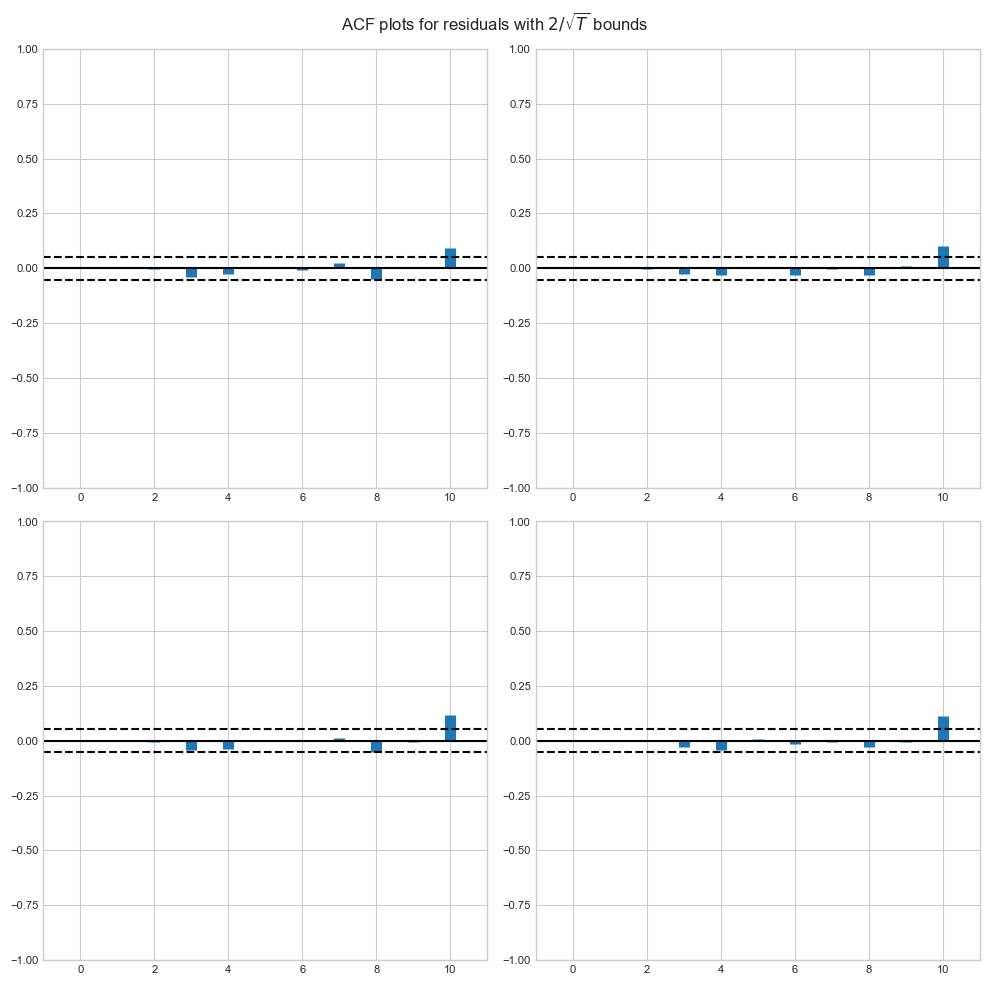

In [9]:
# CELL 9: DIAGNOSTICS - STABILITY + RESIDUAL WHITENESS
is_stable = var_results.is_stable(verbose=True)
print(f"\nStable / ergodic: {is_stable}")

wh = var_results.test_whiteness(nlags=var_results.k_ar + 1)
print(f"Residual whiteness p-value: {round(wh.pvalue, 4)}")

var_results.plot_acorr()
plt.tight_layout()
plt.show()

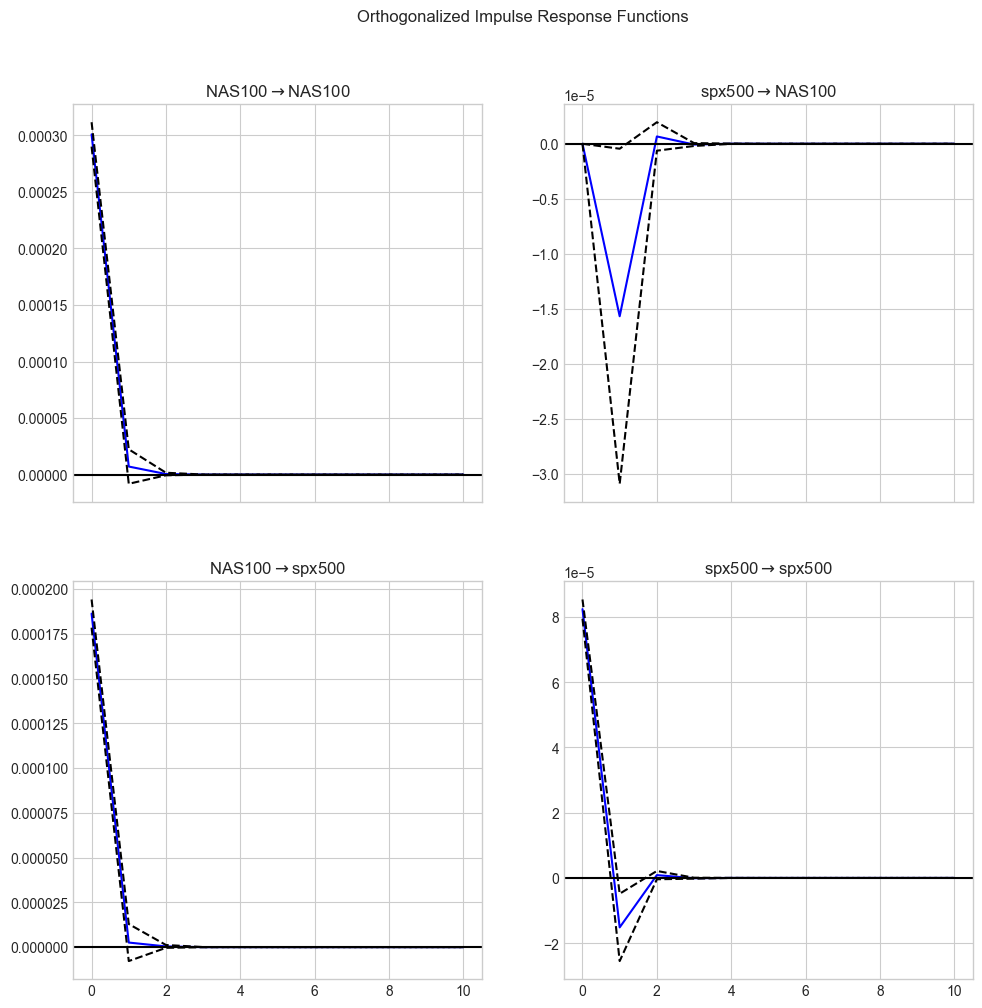

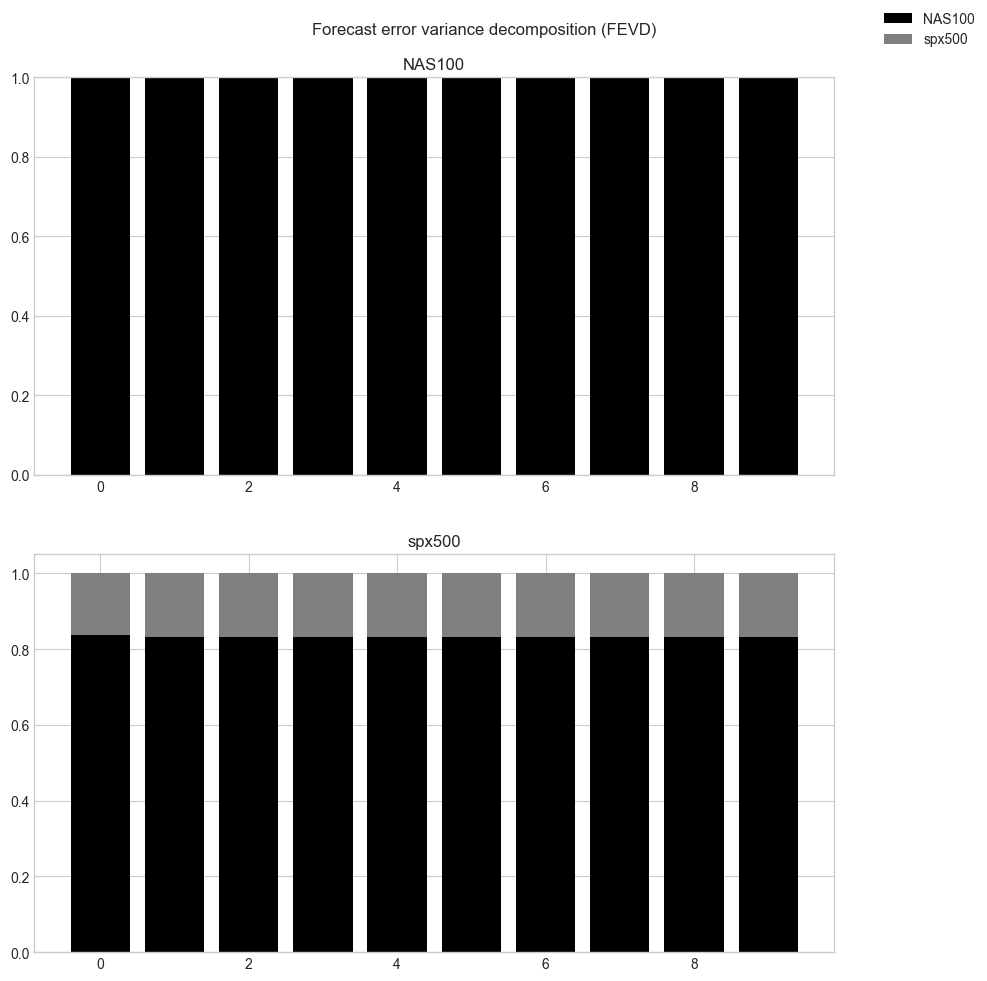

In [10]:
# CELL 10: IRF + FEVD
irf = var_results.irf(periods=10)
irf.plot(orth=True)
plt.suptitle("Orthogonalized Impulse Response Functions", y=1.02)
plt.show()

var_results.fevd(periods=10).plot()
plt.show()

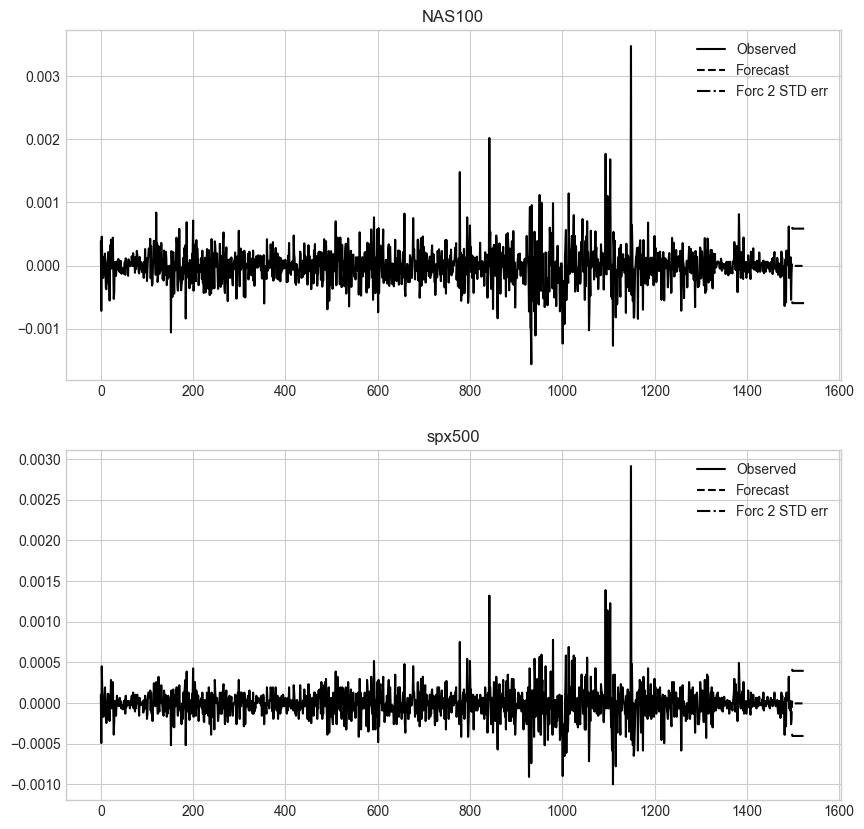

In [11]:
# CELL 11: FIGURE 7 - FORECAST OF DIFFERENCED SERIES
steps = FORECAST_STEPS[TIMEFRAME]
var_results.plot_forecast(steps=steps, alpha=0.05, plot_stderr=True)
plt.show()

                     NAS100Forecast  spx500Forecast
2026-09-29 00:01:00    30341.866255     7697.162809
2026-09-29 00:02:00    30341.661073     7697.124292
2026-09-29 00:03:00    30341.497807     7697.098858
2026-09-29 00:04:00    30341.330655     7697.072319
2026-09-29 00:05:00    30341.163783     7697.045863
2026-09-29 00:06:00    30340.996890     7697.019401
2026-09-29 00:07:00    30340.829999     7696.992939
2026-09-29 00:08:00    30340.663109     7696.966477
2026-09-29 00:09:00    30340.496220     7696.940015
2026-09-29 00:10:00    30340.329332     7696.913553


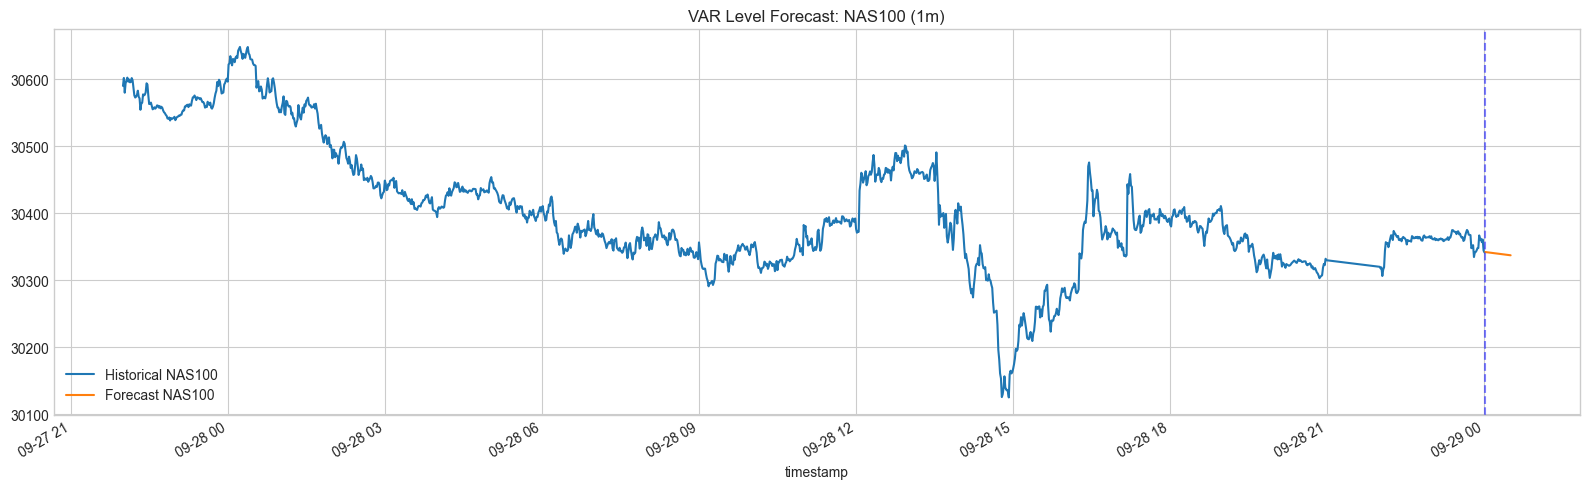

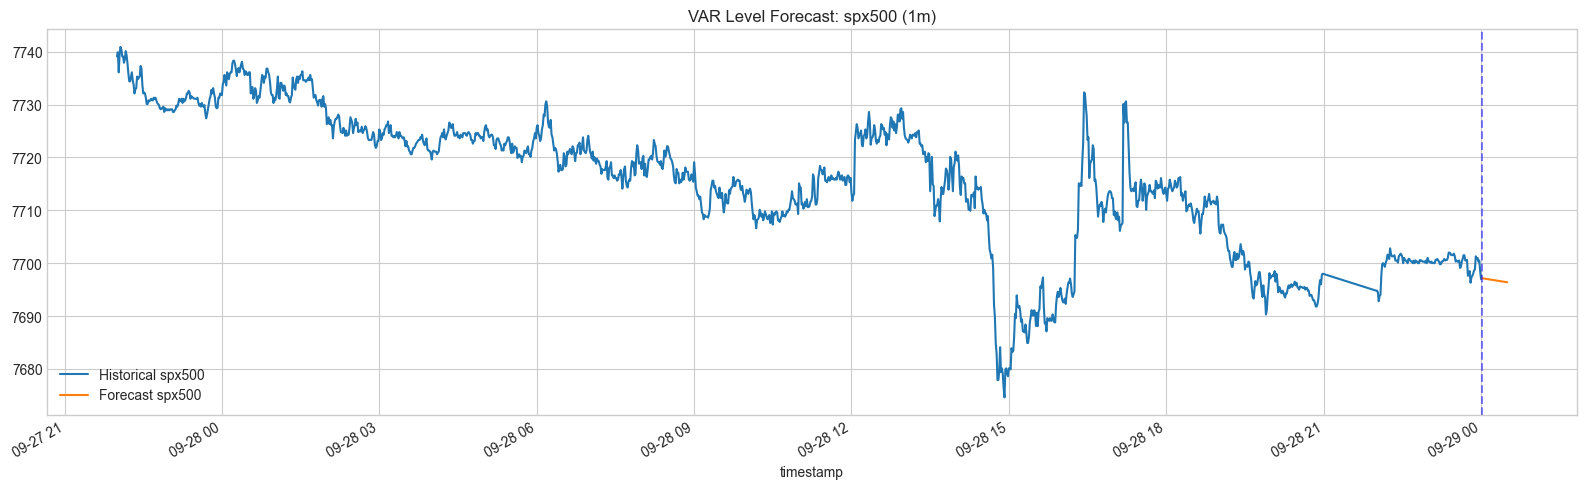

In [12]:
# CELL 12: FIGURE 8 - FORECAST OF LEVELS (log-diff -> cumsum -> exp)
pred = var_results.forecast(y=diff_data.values[-lag_order:], steps=steps)

# intraday: step forward by one bar (does not skip session close)
idx = pd.date_range(start=data.index[-1] + BAR_TD[TIMEFRAME], periods=steps, freq=BAR_TD[TIMEFRAME])
df_forecast = pd.DataFrame(pred, index=idx, columns=[f"{c}_logret" for c in data.columns])

for col in data.columns:
    last_log = np.log(data[col].iloc[-1])
    df_forecast[f"{col}Forecast"] = np.exp(last_log + df_forecast[f"{col}_logret"].cumsum())

print(df_forecast[[f"{c}Forecast" for c in data.columns]].head(10))

for col in data.columns:
    plt.figure(figsize=(16, 5))
    data[col].plot(legend=True, label=f"Historical {col}")
    df_forecast[f"{col}Forecast"].plot(legend=True, label=f"Forecast {col}")
    plt.axvline(x=idx[0], color="b", alpha=0.5, linestyle="--")
    plt.title(f"VAR Level Forecast: {col} ({TIMEFRAME})")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [13]:
'''
Static vs rolling

The files I gave you fit one model on one window and forecast once. That is fine for research and understanding the data.
For live trading you need a rolling (walk-forward) setup:
Keep a fixed window of the most recent N bars (or an expanding one).
Refit the VAR every bar, or every K bars to save time.
Forecast 1 step ahead using only closed bars.
Compare with the actual next bar to measure out-of-sample accuracy.
ADF, Granger and lag selection are research steps. Re-run them daily or weekly, not on every bar. Also re-check stability after each refit.
'''
# Rolling window for live data

WINDOW = 1000          # bars in the training window
REFIT_EVERY = 20       # refit every 20 bars
p = optimal_lag

preds, actual = [], []
for t in range(WINDOW, len(diff_data)):
    if (t - WINDOW) % REFIT_EVERY == 0:
        res = VAR(diff_data.iloc[t - WINDOW:t]).fit(p, trend="c")
        if not res.is_stable():
            print("unstable model at", diff_data.index[t])
    # last p known rows -> forecast bar t (no look-ahead)
    preds.append(res.forecast(diff_data.values[t - p:t], steps=1)[0])
    actual.append(diff_data.values[t])

idx = diff_data.index[WINDOW:]
preds = pd.DataFrame(preds, index=idx, columns=diff_data.columns)
actual = pd.DataFrame(actual, index=idx, columns=diff_data.columns)

hit_rate = (np.sign(preds) == np.sign(actual)).mean()
rmse_var = ((preds - actual) ** 2).mean() ** 0.5
rmse_zero = (actual ** 2).mean() ** 0.5      # naive "no change" benchmark
print("Directional hit rate:\n", hit_rate)
print("RMSE VAR vs zero-forecast:\n", pd.concat([rmse_var, rmse_zero], axis=1, keys=["VAR", "Zero"]))

Directional hit rate:
 NAS100    0.493976
spx500    0.469880
dtype: float64
RMSE VAR vs zero-forecast:
             VAR      Zero
NAS100  0.00034  0.000338
spx500  0.00026  0.000259


In [ ]:
'''
Desks use VAR as a baseline or as a feature, not as the whole strategy.
Better options for the same idea:
NAS100 and SPX500 are probably cointegrated, so a VECM keeps the long-run link that differencing removes.
Volatility models (GARCH) often add more value intraday.
ML models are also common.
'''